In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import re
import string
import nltk

In [100]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words_pt = set(stopwords.words('portuguese'))
stop_words_pt.update(['q', 'qe', 'vc', 'pra', 'mt', 'mto', 'c', 'pro'])

In [101]:
def limpar_texto(texto):

    # 1. Normalização: Tudo para minúsculo
    texto = texto.lower()

    # 2. Remoção de pontuação e números usando Expressões Regulares (Regex)
    # Isso substitui qualquer coisa que não seja letra (a-z, á-ú) por um espaço
    texto = re.sub(r'[^a-záéíóúãõç\s]', ' ', texto)

    # 3. Tokenização: Transforma a frase em uma lista de palavras
    # Ex: "o time jogou mal" -> ['o', 'time', 'jogou', 'mal']
    palavras = word_tokenize(texto, language='portuguese')

    # 4. Remoção de Stop Words
    # Filtra a lista, mantendo apenas palavras que NÃO estão na lista de stop words
    palavras_limpas = [palavra for palavra in palavras if palavra not in stop_words_pt]

    # 5. Reconstrução: Junta a lista de volta em uma única string (frase)
    texto_limpo = " ".join(palavras_limpas)

    return texto_limpo

In [102]:
df = pd.read_csv('dados_sentimentos_organicos.csv')
df['comentario_limpo'] = df['comentario'].apply(limpar_texto)

In [103]:
df

,comentario,sentimento,comentario_limpo
0,esse juiz mds,Positivo,juiz mds
1,o time gigante a diretoria tava o jogo pqp,Positivo,time gigante diretoria tava jogo pqp
2,ruim bagre rs,Negativo,ruim bagre rs
3,velho slc slc lixo a zaga amador,Negativo,velho slc slc lixo zaga amador
4,vergonha jogou mt esse cara ne pqp gigante,Positivo,vergonha jogou cara ne pqp gigante
...,...,...,...
2915,gigante vergonha horrivel esse cara,Positivo,gigante vergonha horrivel cara
2916,lixoo tudoo manoo pqp,Negativo,lixoo tudoo manoo pqp
2917,esse juiz voandoo amassou meu deus,Positivo,juiz voandoo amassou deus
2918,tava a zaga horrivel bagre bagre gigante,Negativo,tava zaga horrivel bagre bagre gigante


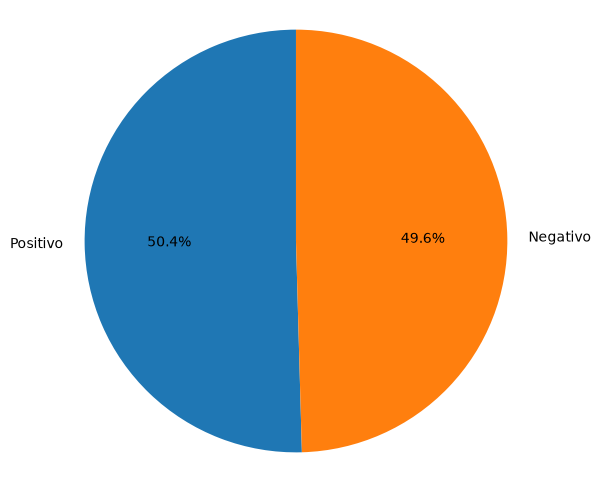

In [104]:
#Verificando a distribuição dos sentimentos
sentimentos = df.value_counts('sentimento')
plt.figure(figsize=(6,6))
plt.pie(sentimentos, labels=sentimentos.index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

In [105]:
# Criando o vetorizer TF-IDF
tfidf = TfidfVectorizer(max_features=5000)  # Usando o max limitando a 5000 palavras mais frequentes para evitar dimensionalidade excessiva

# Aplicando o TF-IDF na coluna de texto
X = tfidf.fit_transform(df['comentario_limpo'])  # Transformando as avaliações de texto em uma matriz de características numéricas. afinal em modelos trabalhamos com números

In [106]:
palavras = tfidf.get_feature_names_out()

# Calculando a média dos valores de aparições de cada palavra
mean_tfidf = X.toarray().mean(axis=0)

# Criando um DataFrame com as palavras e seus valores médios de TF-IDF
tfidf_df = pd.DataFrame(data={'Word': palavras, 'Mean_TFIDF': mean_tfidf})
tfidf_df = tfidf_df.sort_values(by='Mean_TFIDF', ascending=False)

print(tfidf_df.head(20))

         Word  Mean_TFIDF
8        cara    0.076643
10       deus    0.060658
25       juiz    0.053825
3      ataque    0.053694
48    tecnico    0.052110
58       zaga    0.051989
50       time    0.050879
11  diretoria    0.050630
19         hj    0.050235
22       jogo    0.046655
17    goleiro    0.044795
38         oo    0.042090
33        mds    0.041124
47       tava    0.040711
5       bagre    0.040109
42      podre    0.040025
9      craque    0.039603
1     amassou    0.039403
55   vergonha    0.039120
4        aula    0.039065


In [107]:
stop_words_personalizadas = [
    'o', 'a', 'os', 'as', 'do', 'da', 'dos', 'das', 'de', 'que', 'ao', 'aos',
    'um', 'uma', 'uns', 'umas', 'para', 'é', 'essa', 'esse', 'na', 'no',
    'nas', 'nos', 'cada', 'em', 'com', 'por', 'como', 'sua', 'seu']

In [108]:
#  Refazemos o TF-IDF na coluna de texto, removendo as stop words personalizadas
tfidf_2 = TfidfVectorizer(max_features=5000, stop_words= stop_words_personalizadas)  # Usando a lista personalizada
X = tfidf_2.fit_transform(df['comentario_limpo'])

In [109]:
palavras = tfidf_2.get_feature_names_out()
mean_tfidf = X.toarray().mean(axis=0)
tfidf_df = pd.DataFrame(data={'Word': palavras, 'Mean_TFIDF': mean_tfidf})
tfidf_df = tfidf_df.sort_values(by='Mean_TFIDF', ascending=False)
print(tfidf_df.head(20))

         Word  Mean_TFIDF
8        cara    0.076643
10       deus    0.060658
25       juiz    0.053825
3      ataque    0.053694
48    tecnico    0.052110
58       zaga    0.051989
50       time    0.050879
11  diretoria    0.050630
19         hj    0.050235
22       jogo    0.046655
17    goleiro    0.044795
38         oo    0.042090
33        mds    0.041124
47       tava    0.040711
5       bagre    0.040109
42      podre    0.040025
9      craque    0.039603
1     amassou    0.039403
55   vergonha    0.039120
4        aula    0.039065


In [110]:
label_encoder = LabelEncoder()
df['sentimento'] = label_encoder.fit_transform(df['sentimento'])

In [111]:
y = df['sentimento']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
#Treino do modelo
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [113]:
y_pred = model.predict(X_test)

In [114]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy:.2f}')

# Matriz
conf_matrix = confusion_matrix(y_test, y_pred)
print('Matriz de Confusão:')
print(conf_matrix)

class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_.astype(str))

print('Relatório de Classificação:')
print(class_report)

Acurácia: 0.75
Matriz de Confusão:
[[202  65]
 [ 80 237]]
Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.72      0.76      0.74       267
    Positivo       0.78      0.75      0.77       317

    accuracy                           0.75       584
   macro avg       0.75      0.75      0.75       584
weighted avg       0.75      0.75      0.75       584



In [116]:
# 1. Obter os índices do DataFrame original para o conjunto de teste
test_indices = df.index[y_train.shape[0]:]  # Índices que não estão no conjunto de treino

# 2. Recuperar as frases do conjunto de teste usando os índices corretos
test_sentences = df['comentario_limpo'].iloc[test_indices]

# 3. Criar um DataFrame com frases, classes verdadeiras e previsões
results_df = pd.DataFrame({
    'Frase': test_sentences.values,  # Usando as frases corretas como corespondentes
    'Classe Verdadeira': y_test,
    'Previsão': y_pred
})

# 4. Convertendo a coluna das classes novamente para neg e pos
results_df['Classe Verdadeira'] = label_encoder.inverse_transform(results_df['Classe Verdadeira'])
results_df['Previsão'] = label_encoder.inverse_transform(results_df['Previsão'])

print(results_df.head(10))

                                          Frase Classe Verdadeira  Previsão
2437                   ataque tecnico nada kkkk          Positivo  Positivo
2470                            jogo genio jogo          Positivo  Negativo
2359         deus diretoria vergonha goleiro ne          Positivo  Positivo
789                         assim entregou nada          Negativo  Negativo
1642      tudo entregou vergonha time time cara          Positivo  Negativo
196                          genio goleiro jogo          Positivo  Positivo
1543  oo goleiroo nada manoo gigante oo goleiro          Positivo  Positivo
1270               lixo ne bagre bagre entregou          Positivo  Positivo
2473         hoje pqp zaga lindoo pipocou lindo          Negativo  Negativo
2073              brabo bagre jogou juiz craque          Positivo  Positivo
